In [1]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt

tables = [
    "O2kinkcands",
    "O2lambda1405"
]

like_sign_file = "/home/mdicosta/LocalTestsO2/Lambda1405/LikeSign/Tree.root"
unlike_sign_file = "/home/mdicosta/LocalTestsO2/Lambda1405/UnlikeSign/Tree.root"

ROOT Keys: ['DF_2337256861756704;1', 'DF_2337256861756704/O2kinkcands;1', 'DF_2337256861756704/O2lambda1405;1', 'DF_2337256861756704/O2lambda1405flow;1', 'parentFiles;1']
Reading DF_2337256861756704/O2kinkcands;1

Table: O2kinkcands
Number of entries: 154484
Columns: ['fIndexCollisions', 'fIndexTracksIU_Moth', 'fIndexTracksIU_Daug', 'fXDecVtx', 'fYDecVtx', 'fZDecVtx', 'fMothSign', 'fPxMoth', 'fPyMoth', 'fPzMoth', 'fPxDaug', 'fPyDaug', 'fPzDaug', 'fDcaMothPv', 'fDcaDaugPv', 'fDcaKinkTopo']
Plotting fIndexCollisions
Plotting fIndexTracksIU_Moth
Plotting fIndexTracksIU_Daug
Plotting fXDecVtx
Plotting fYDecVtx
Plotting fZDecVtx
Plotting fMothSign
Plotting fPxMoth
Plotting fPyMoth
Plotting fPzMoth
Plotting fPxDaug
Plotting fPyDaug
Plotting fPzDaug
Plotting fDcaMothPv
Plotting fDcaDaugPv
Plotting fDcaKinkTopo


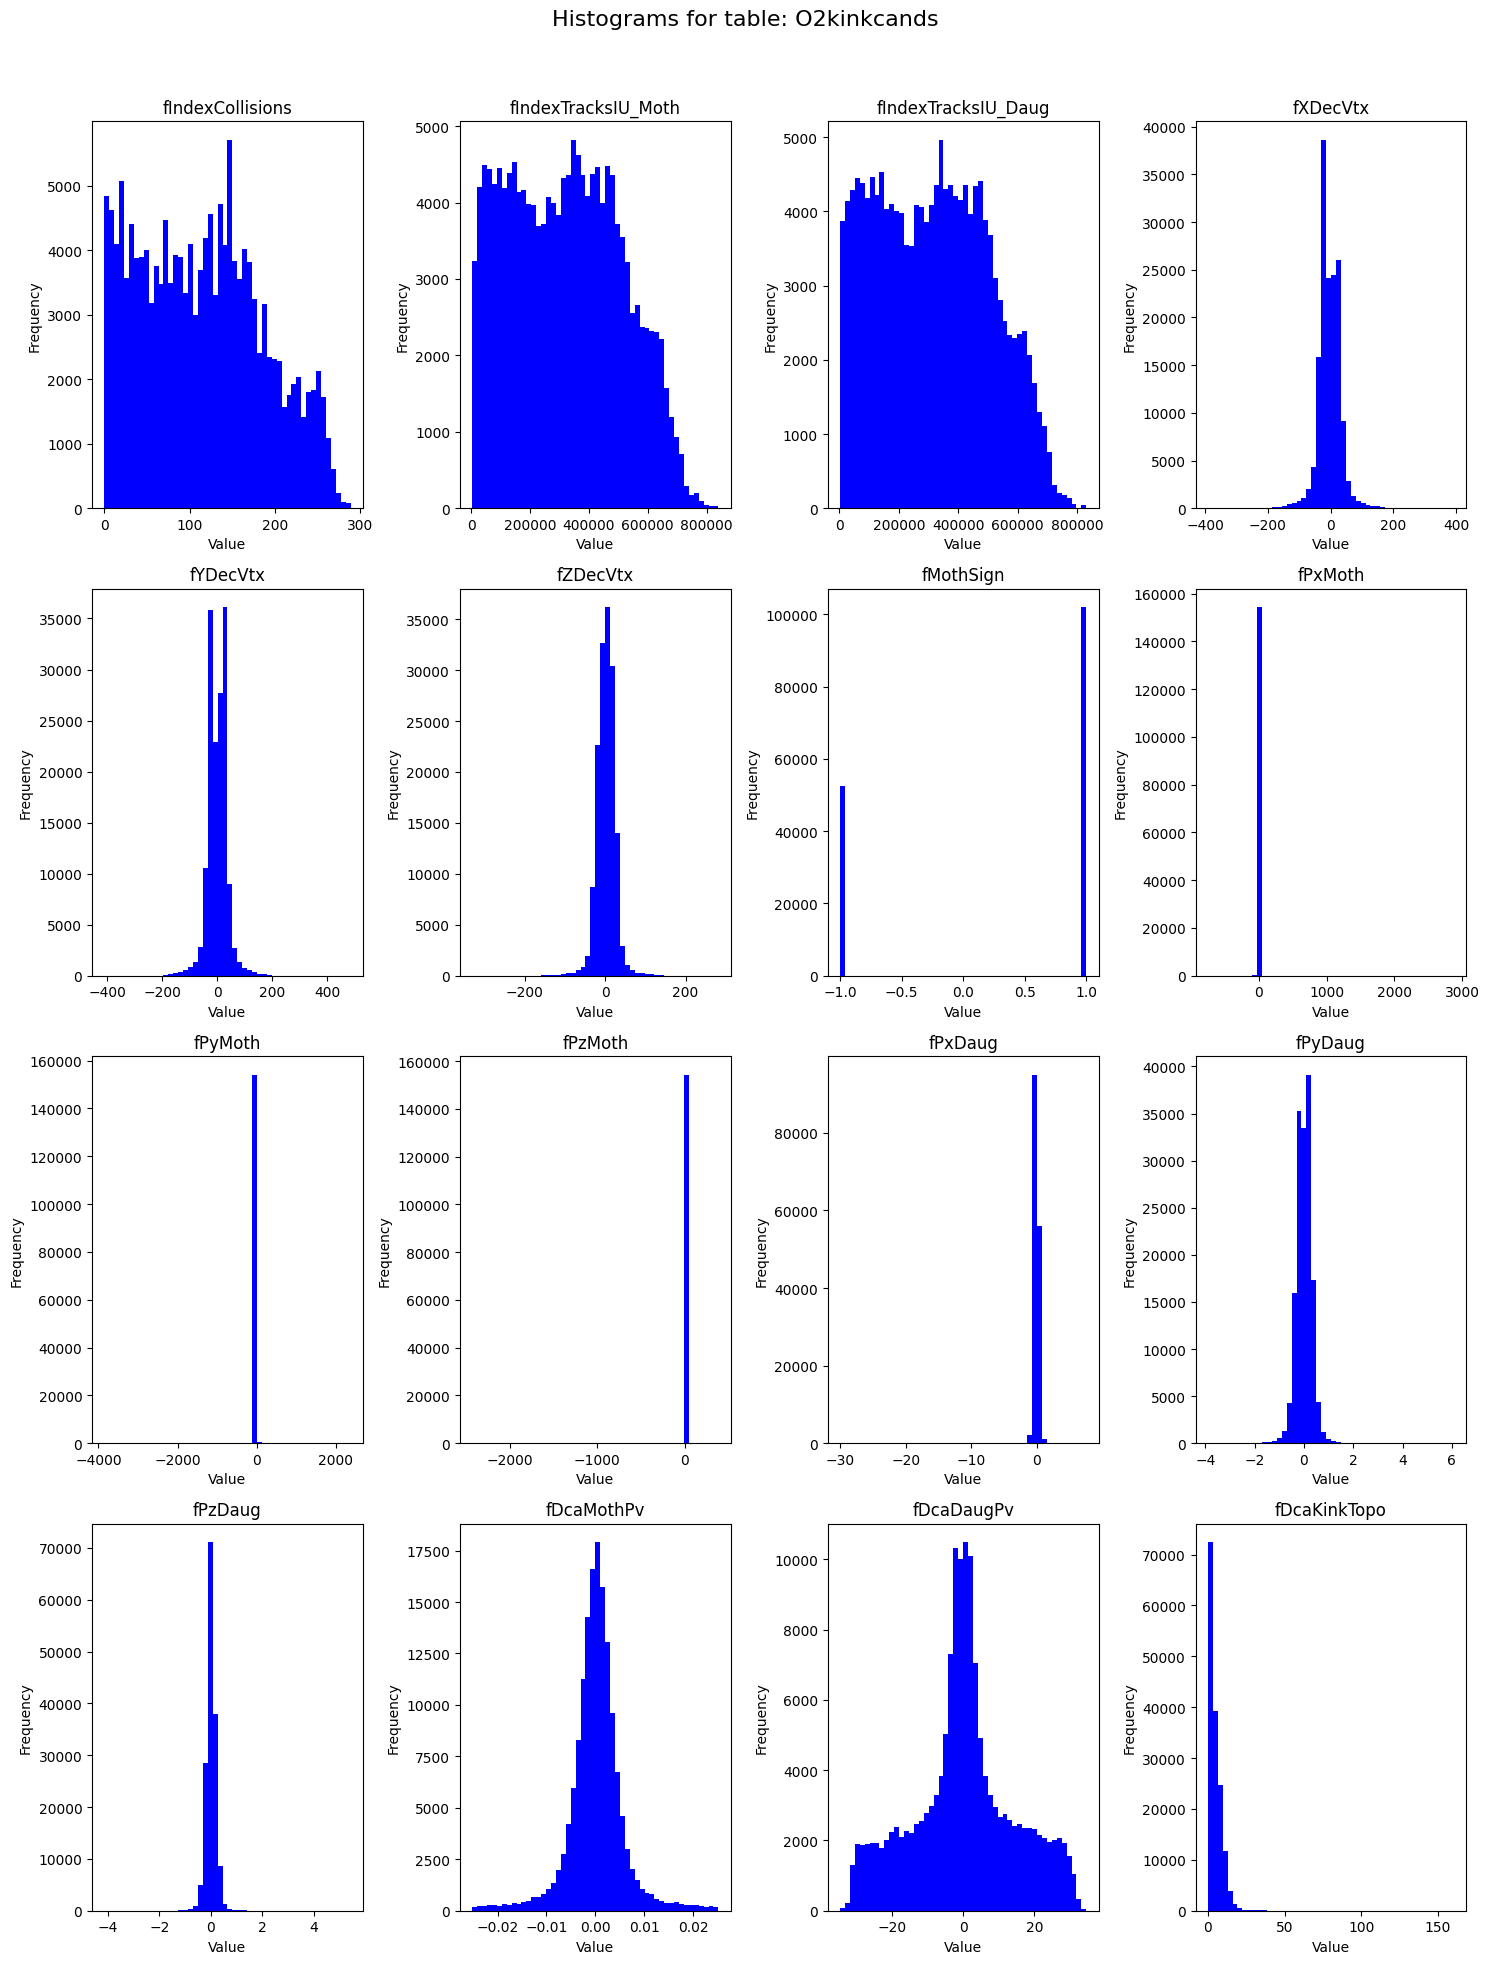

Reading DF_2337256861756704/O2lambda1405;1

Table: O2lambda1405
Number of entries: 777021
Columns: ['fPx', 'fPy', 'fPz', 'fMass', 'fMassXi1530', 'fSigmaMinusMass', 'fSigmaPlusMass', 'fXiMinusMass', 'fPtSigma', 'fAlphaAPSigma', 'fQtAPSigma', 'fRadiusSigma', 'fPtKink', 'fNSigmaTPCPiKink', 'fNSigmaTOFPiKink', 'fNSigmaTPCPrKink', 'fNSigmaTOFPrKink', 'fDCAKinkDauToPV', 'fNSigmaTPCPiDau', 'fNSigmaTOFPiDau']
Plotting fPx
Plotting fPy
Plotting fPz
Plotting fMass
Plotting fMassXi1530
Plotting fSigmaMinusMass
Plotting fSigmaPlusMass
Plotting fXiMinusMass
Plotting fPtSigma
Plotting fAlphaAPSigma
Plotting fQtAPSigma
Plotting fRadiusSigma
Plotting fPtKink
Plotting fNSigmaTPCPiKink
Plotting fNSigmaTOFPiKink
Plotting fNSigmaTPCPrKink
Plotting fNSigmaTOFPrKink
Plotting fDCAKinkDauToPV
Plotting fNSigmaTPCPiDau
Plotting fNSigmaTOFPiDau


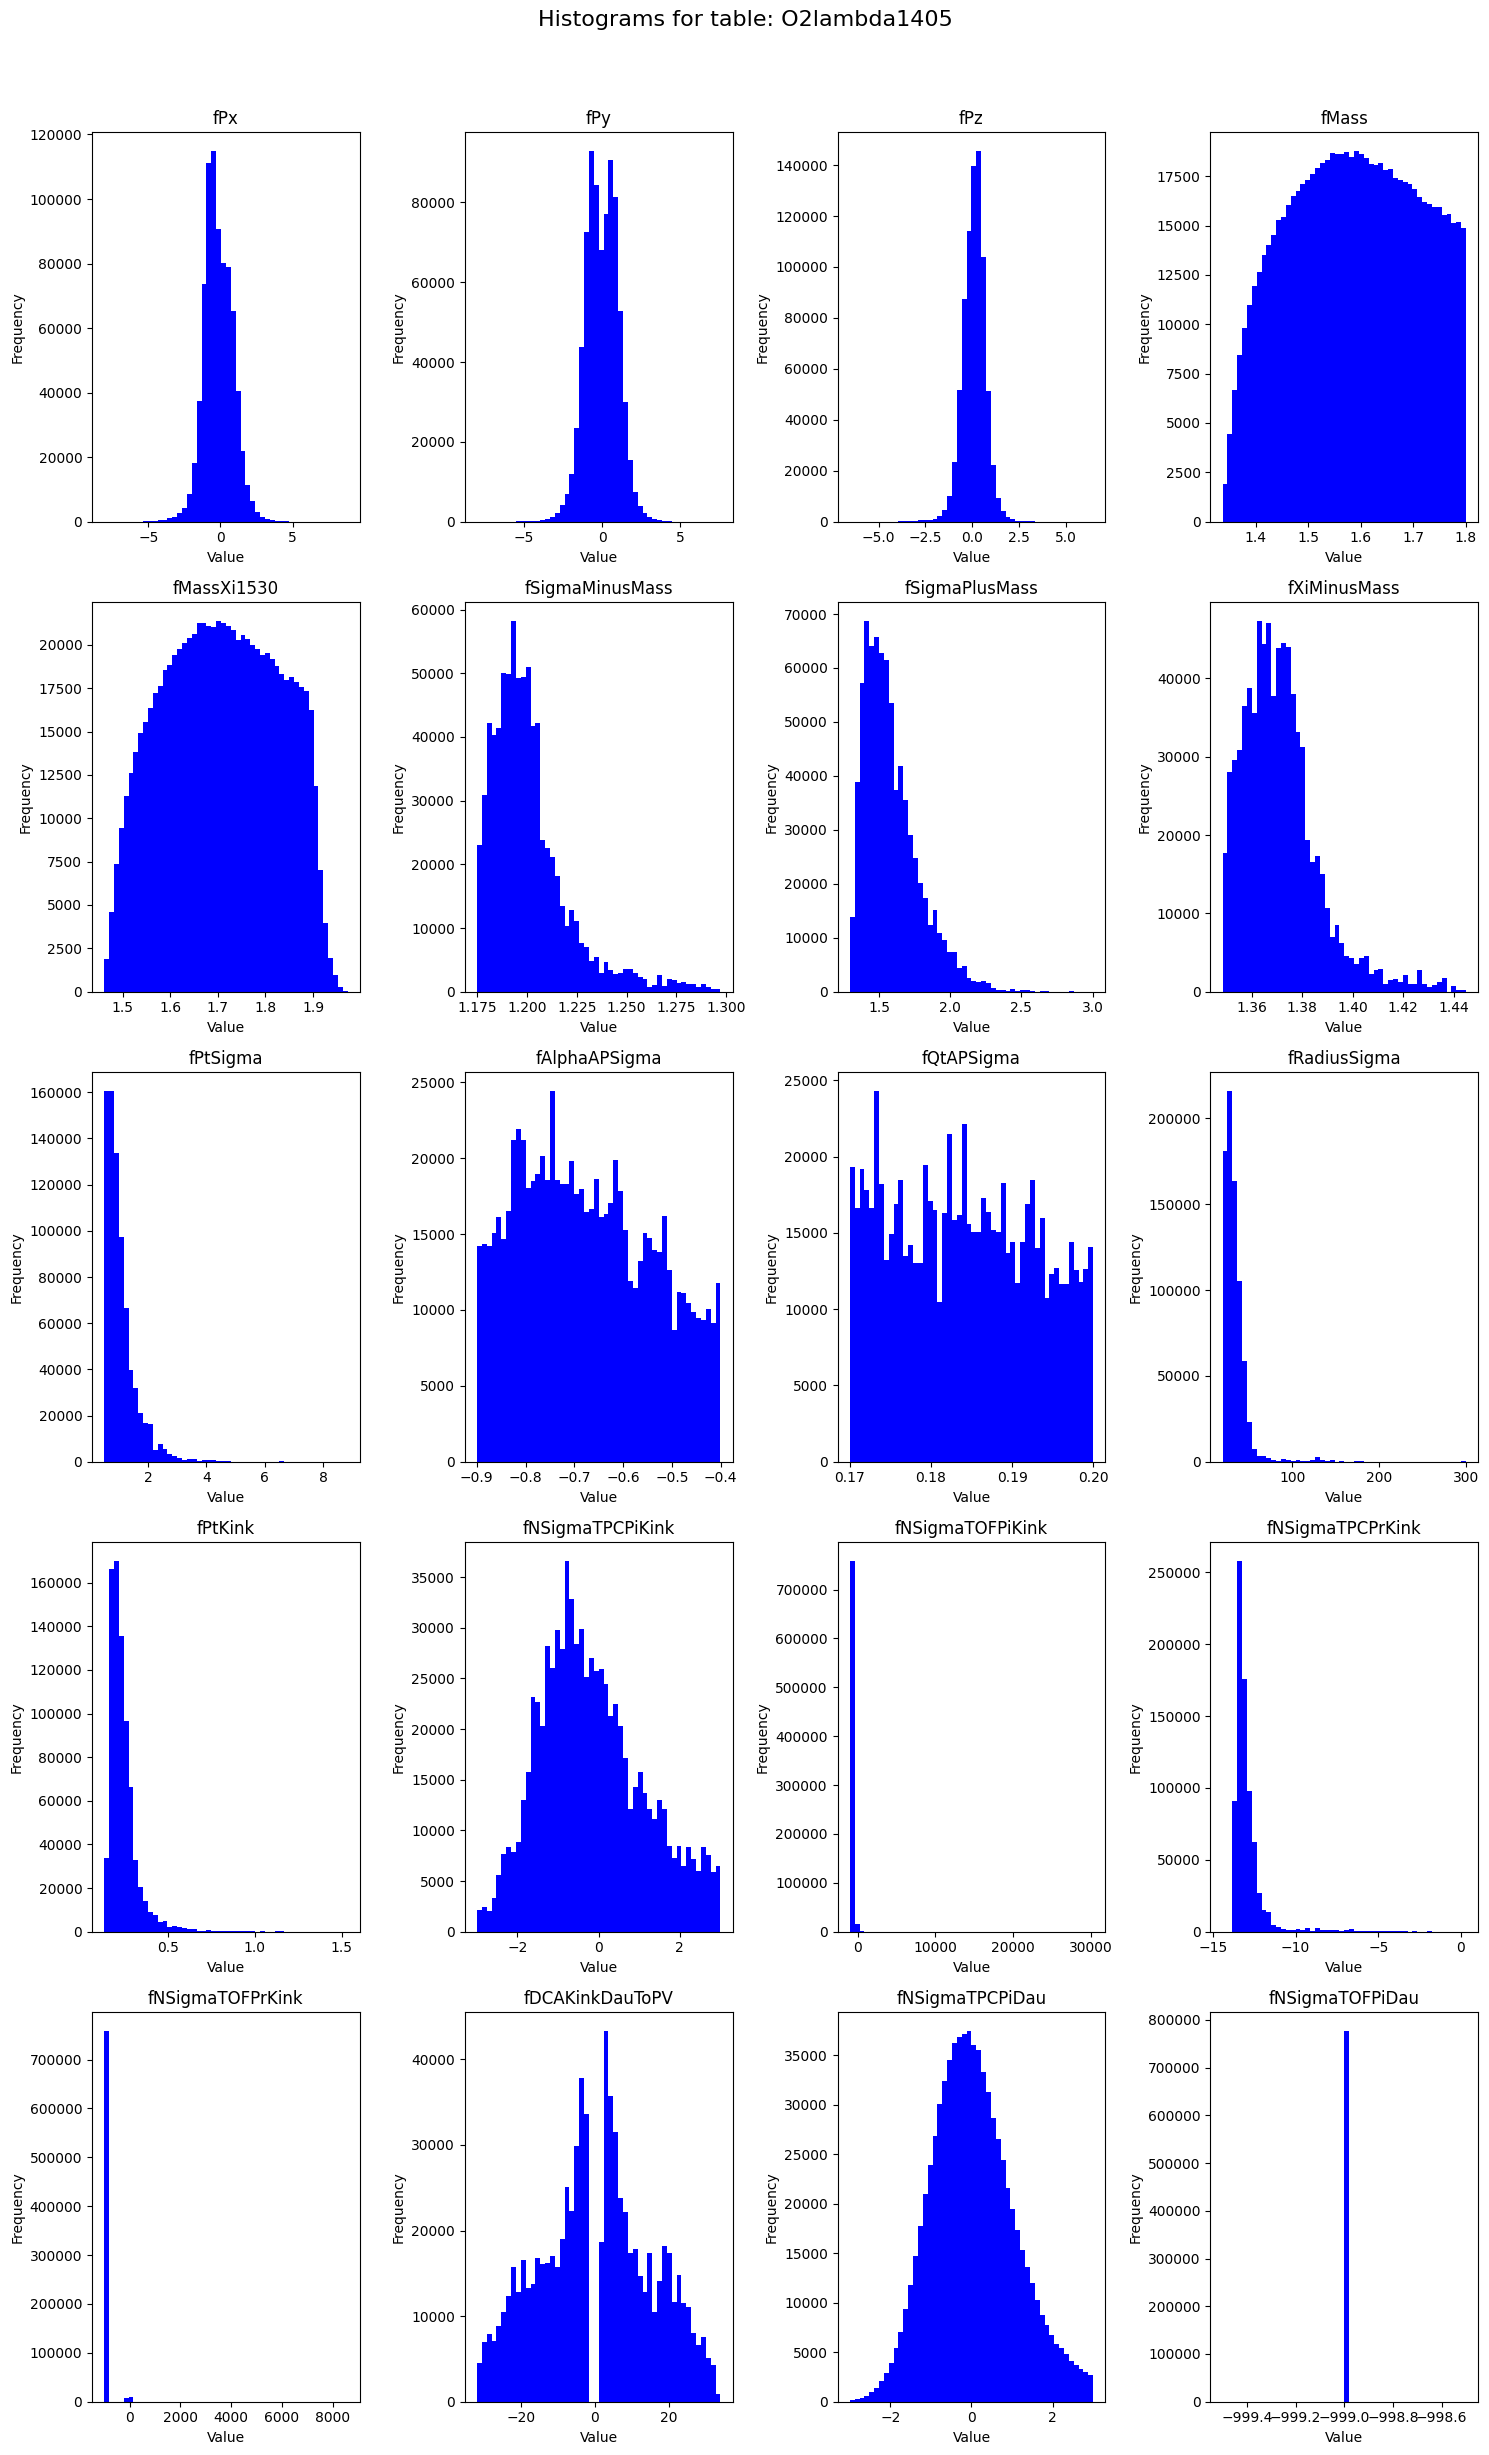


Dictionary keys:
dict_keys(['O2kinkcands.fIndexCollisions', 'O2kinkcands.fIndexTracksIU_Moth', 'O2kinkcands.fIndexTracksIU_Daug', 'O2kinkcands.fXDecVtx', 'O2kinkcands.fYDecVtx', 'O2kinkcands.fZDecVtx', 'O2kinkcands.fMothSign', 'O2kinkcands.fPxMoth', 'O2kinkcands.fPyMoth', 'O2kinkcands.fPzMoth', 'O2kinkcands.fPxDaug', 'O2kinkcands.fPyDaug', 'O2kinkcands.fPzDaug', 'O2kinkcands.fDcaMothPv', 'O2kinkcands.fDcaDaugPv', 'O2kinkcands.fDcaKinkTopo', 'O2lambda1405.fPx', 'O2lambda1405.fPy', 'O2lambda1405.fPz', 'O2lambda1405.fMass', 'O2lambda1405.fMassXi1530', 'O2lambda1405.fSigmaMinusMass', 'O2lambda1405.fSigmaPlusMass', 'O2lambda1405.fXiMinusMass', 'O2lambda1405.fPtSigma', 'O2lambda1405.fAlphaAPSigma', 'O2lambda1405.fQtAPSigma', 'O2lambda1405.fRadiusSigma', 'O2lambda1405.fPtKink', 'O2lambda1405.fNSigmaTPCPiKink', 'O2lambda1405.fNSigmaTOFPiKink', 'O2lambda1405.fNSigmaTPCPrKink', 'O2lambda1405.fNSigmaTOFPrKink', 'O2lambda1405.fDCAKinkDauToPV', 'O2lambda1405.fNSigmaTPCPiDau', 'O2lambda1405.fNSigma

In [2]:
all_data_like_sign = {}

with uproot.open(like_sign_file) as f:
    keys = f.keys()
    print("ROOT Keys:", keys)

    for table in tables:
        # Filter keys matching the table name
        matched_keys = [key for key in keys if f"{table};" in key]

        if not matched_keys:
            print(f"No keys found for table: {table}")
            continue

        dfs = []

        for key in matched_keys:
            print(f"Reading {key}")
            df = f[key].arrays(library="pd")
            dfs.append(df)

        # Merge all chunks of the table
        full_df = pd.concat(dfs, ignore_index=True)

        print(f"\nTable: {table}")
        print(f"Number of entries: {len(full_df)}")
        print(f"Columns: {full_df.columns.tolist()}")

        # ==========================================================
        # Store columns into flat dictionary
        # ==========================================================
        for column in full_df.columns:
            dict_key = f"{table}.{column}"

            # Convert column to plain Python list
            all_data_like_sign[dict_key] = full_df[column].dropna().tolist()

        # ==========================================================
        # Plotting
        # ==========================================================
        n_columns = len(full_df.columns)
        n_rows = (n_columns // 4) + (1 if n_columns % 4 else 0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(15, 5 * n_rows))

        # Handle case with only one row
        if n_rows == 1:
            axes = axes.reshape(-1)

        axes = axes.flatten()

        for i, column in enumerate(full_df.columns):
            print(f"Plotting {column}")

            try:
                data = full_df[column].dropna()

                # Plot only numeric columns
                if pd.api.types.is_numeric_dtype(data):
                    axes[i].hist(data, bins=50, color='blue')
                    axes[i].set_title(column)
                    axes[i].set_xlabel("Value")
                    axes[i].set_ylabel("Frequency")
                else:
                    axes[i].text(
                        0.5, 0.5,
                        "Non-numeric column",
                        ha='center',
                        va='center'
                    )
                    axes[i].set_title(column)

            except Exception as e:
                print(f"Could not plot column {column}: {e}")
                axes[i].set_visible(False)

        # # Remove unused axes
        # for i in range(n_columns, len(axes)):
        #     fig.delaxes(axes[i])

        fig.suptitle(f"Histograms for table: {table}", fontsize=16)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# ==========================================================
# Example usage of the dictionary
# ==========================================================

print("\nDictionary keys:")
print(all_data_like_sign.keys())

ROOT Keys: ['DF_2337256861756704;1', 'DF_2337256861756704/O2kinkcands;1', 'DF_2337256861756704/O2lambda1405;1', 'DF_2337256861756704/O2lambda1405flow;1', 'parentFiles;1']
Reading DF_2337256861756704/O2kinkcands;1

Table: O2kinkcands
Number of entries: 91548
Columns: ['fIndexCollisions', 'fIndexTracksIU_Moth', 'fIndexTracksIU_Daug', 'fXDecVtx', 'fYDecVtx', 'fZDecVtx', 'fMothSign', 'fPxMoth', 'fPyMoth', 'fPzMoth', 'fPxDaug', 'fPyDaug', 'fPzDaug', 'fDcaMothPv', 'fDcaDaugPv', 'fDcaKinkTopo']
Plotting fIndexCollisions
Plotting fIndexTracksIU_Moth
Plotting fIndexTracksIU_Daug
Plotting fXDecVtx
Plotting fYDecVtx
Plotting fZDecVtx
Plotting fMothSign
Plotting fPxMoth
Plotting fPyMoth
Plotting fPzMoth


Plotting fPxDaug
Plotting fPyDaug
Plotting fPzDaug
Plotting fDcaMothPv
Plotting fDcaDaugPv
Plotting fDcaKinkTopo


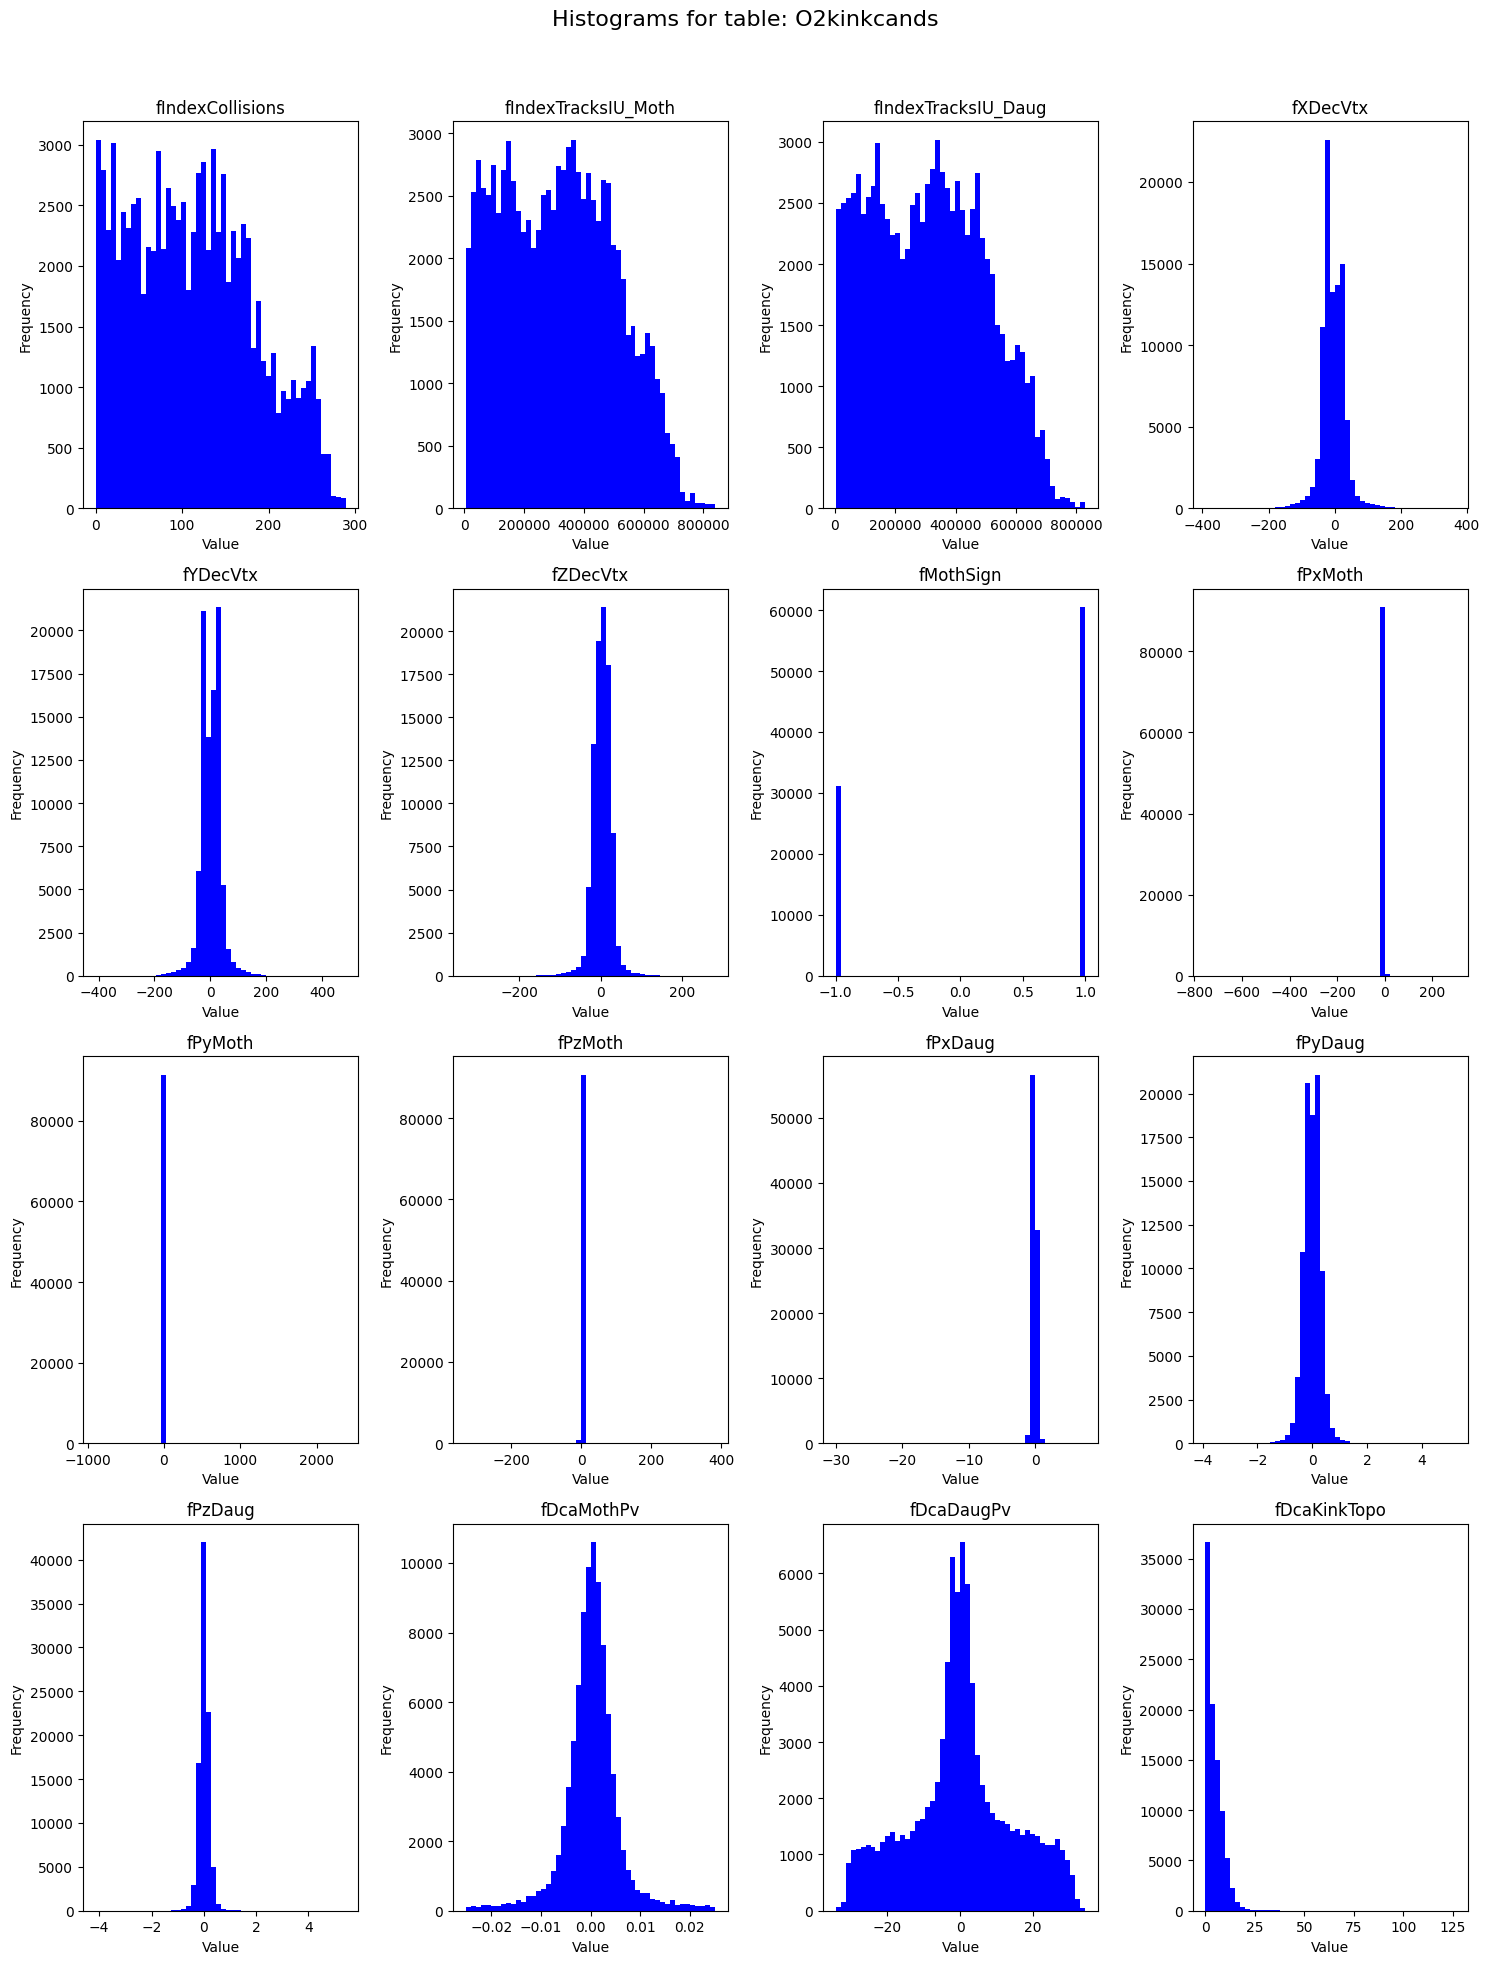

Reading DF_2337256861756704/O2lambda1405;1

Table: O2lambda1405
Number of entries: 455604
Columns: ['fPx', 'fPy', 'fPz', 'fMass', 'fMassXi1530', 'fSigmaMinusMass', 'fSigmaPlusMass', 'fXiMinusMass', 'fPtSigma', 'fAlphaAPSigma', 'fQtAPSigma', 'fRadiusSigma', 'fPtKink', 'fNSigmaTPCPiKink', 'fNSigmaTOFPiKink', 'fNSigmaTPCPrKink', 'fNSigmaTOFPrKink', 'fDCAKinkDauToPV', 'fNSigmaTPCPiDau', 'fNSigmaTOFPiDau']
Plotting fPx
Plotting fPy
Plotting fPz
Plotting fMass
Plotting fMassXi1530
Plotting fSigmaMinusMass
Plotting fSigmaPlusMass
Plotting fXiMinusMass
Plotting fPtSigma
Plotting fAlphaAPSigma
Plotting fQtAPSigma
Plotting fRadiusSigma
Plotting fPtKink
Plotting fNSigmaTPCPiKink
Plotting fNSigmaTOFPiKink
Plotting fNSigmaTPCPrKink
Plotting fNSigmaTOFPrKink
Plotting fDCAKinkDauToPV
Plotting fNSigmaTPCPiDau
Plotting fNSigmaTOFPiDau


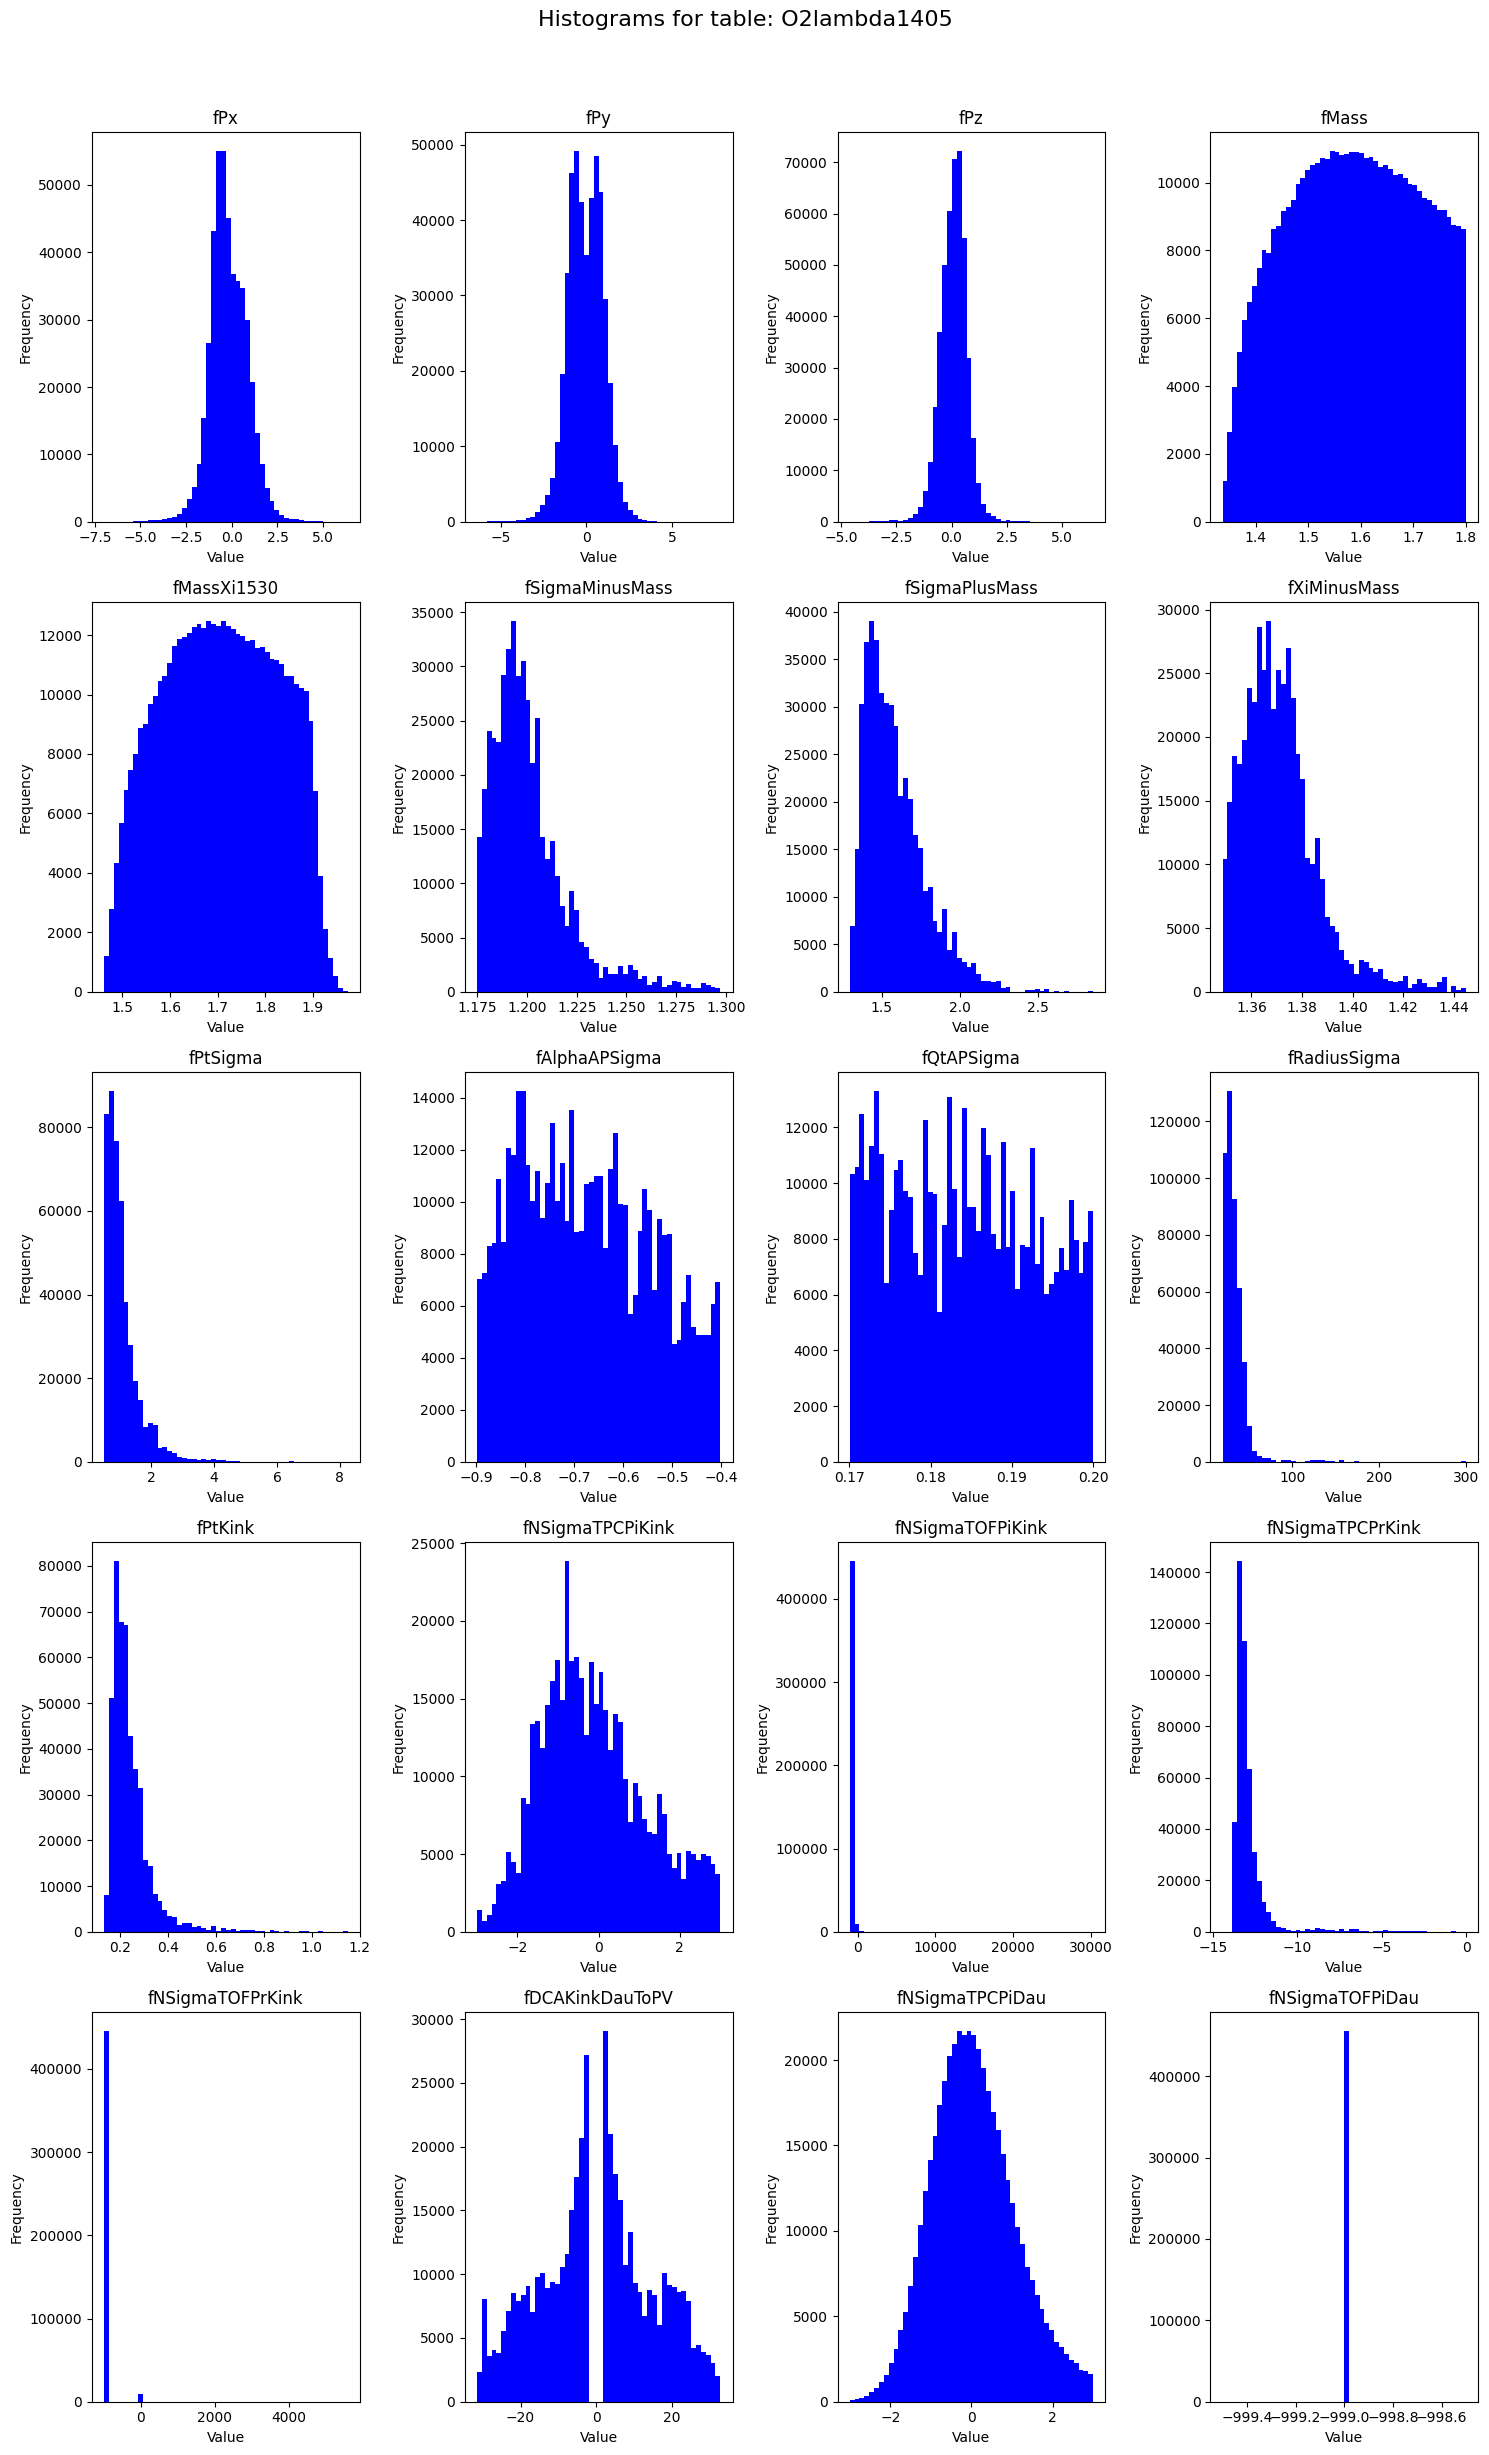


Dictionary keys:
dict_keys(['O2kinkcands.fIndexCollisions', 'O2kinkcands.fIndexTracksIU_Moth', 'O2kinkcands.fIndexTracksIU_Daug', 'O2kinkcands.fXDecVtx', 'O2kinkcands.fYDecVtx', 'O2kinkcands.fZDecVtx', 'O2kinkcands.fMothSign', 'O2kinkcands.fPxMoth', 'O2kinkcands.fPyMoth', 'O2kinkcands.fPzMoth', 'O2kinkcands.fPxDaug', 'O2kinkcands.fPyDaug', 'O2kinkcands.fPzDaug', 'O2kinkcands.fDcaMothPv', 'O2kinkcands.fDcaDaugPv', 'O2kinkcands.fDcaKinkTopo', 'O2lambda1405.fPx', 'O2lambda1405.fPy', 'O2lambda1405.fPz', 'O2lambda1405.fMass', 'O2lambda1405.fMassXi1530', 'O2lambda1405.fSigmaMinusMass', 'O2lambda1405.fSigmaPlusMass', 'O2lambda1405.fXiMinusMass', 'O2lambda1405.fPtSigma', 'O2lambda1405.fAlphaAPSigma', 'O2lambda1405.fQtAPSigma', 'O2lambda1405.fRadiusSigma', 'O2lambda1405.fPtKink', 'O2lambda1405.fNSigmaTPCPiKink', 'O2lambda1405.fNSigmaTOFPiKink', 'O2lambda1405.fNSigmaTPCPrKink', 'O2lambda1405.fNSigmaTOFPrKink', 'O2lambda1405.fDCAKinkDauToPV', 'O2lambda1405.fNSigmaTPCPiDau', 'O2lambda1405.fNSigma

In [3]:
all_data_unlike_sign = {}

with uproot.open(unlike_sign_file) as f:
    keys = f.keys()
    print("ROOT Keys:", keys)

    for table in tables:
        # Filter keys matching the table name
        matched_keys = [key for key in keys if f"{table};" in key]

        if not matched_keys:
            print(f"No keys found for table: {table}")
            continue

        dfs = []

        for key in matched_keys:
            print(f"Reading {key}")
            df = f[key].arrays(library="pd")
            dfs.append(df)

        # Merge all chunks of the table
        full_df = pd.concat(dfs, ignore_index=True)

        print(f"\nTable: {table}")
        print(f"Number of entries: {len(full_df)}")
        print(f"Columns: {full_df.columns.tolist()}")

        # ==========================================================
        # Store columns into flat dictionary
        # ==========================================================
        for column in full_df.columns:
            dict_key = f"{table}.{column}"

            # Convert column to plain Python list
            all_data_unlike_sign[dict_key] = full_df[column].dropna().tolist()

        # ==========================================================
        # Plotting
        # ==========================================================
        n_columns = len(full_df.columns)
        n_rows = (n_columns // 4) + (1 if n_columns % 4 else 0)

        fig, axes = plt.subplots(n_rows, 4, figsize=(15, 5 * n_rows))

        # Handle case with only one row
        if n_rows == 1:
            axes = axes.reshape(-1)

        axes = axes.flatten()

        for i, column in enumerate(full_df.columns):
            print(f"Plotting {column}")

            try:
                data = full_df[column].dropna()

                # Plot only numeric columns
                if pd.api.types.is_numeric_dtype(data):
                    axes[i].hist(data, bins=50, color='blue')
                    axes[i].set_title(column)
                    axes[i].set_xlabel("Value")
                    axes[i].set_ylabel("Frequency")
                else:
                    axes[i].text(
                        0.5, 0.5,
                        "Non-numeric column",
                        ha='center',
                        va='center'
                    )
                    axes[i].set_title(column)

            except Exception as e:
                print(f"Could not plot column {column}: {e}")
                axes[i].set_visible(False)

        # # Remove unused axes
        # for i in range(n_columns, len(axes)):
        #     fig.delaxes(axes[i])

        fig.suptitle(f"Histograms for table: {table}", fontsize=16)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# ==========================================================
# Example usage of the dictionary
# ==========================================================

print("\nDictionary keys:")
print(all_data_unlike_sign.keys())

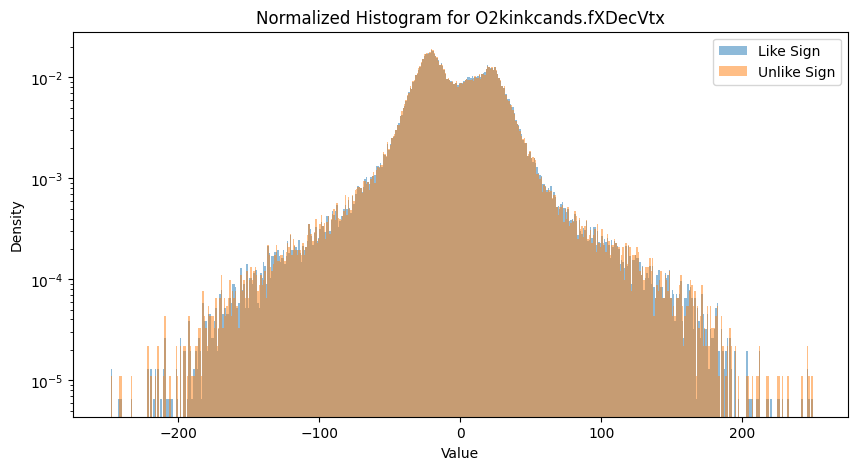

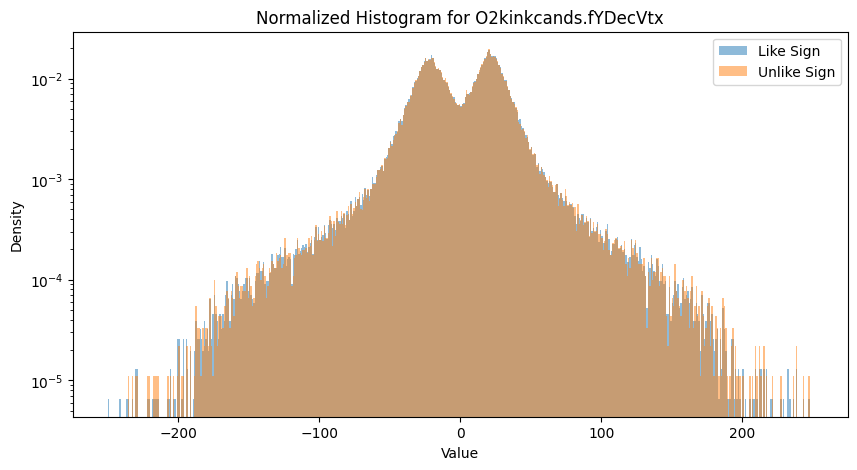

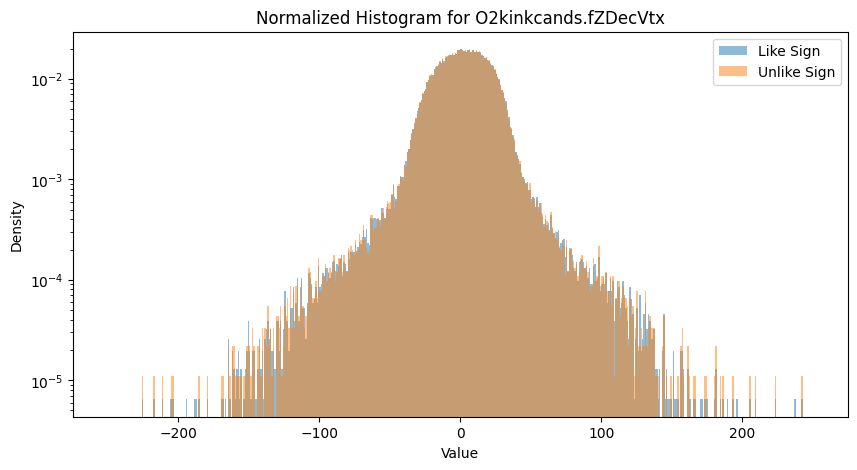

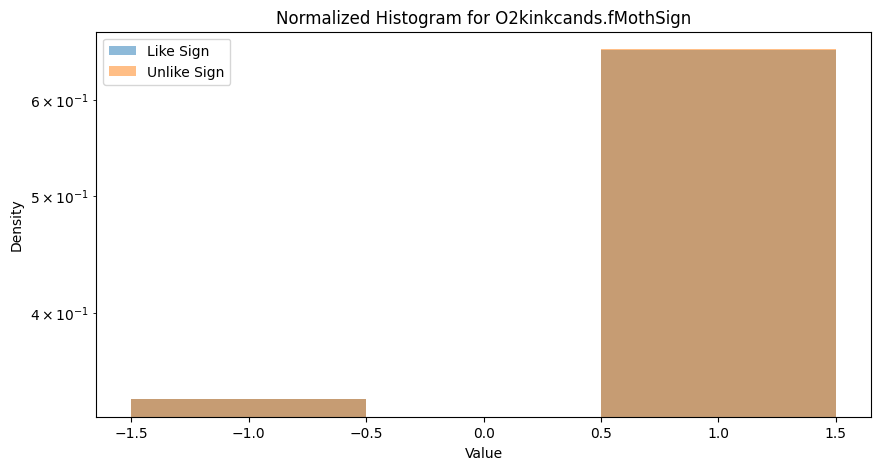

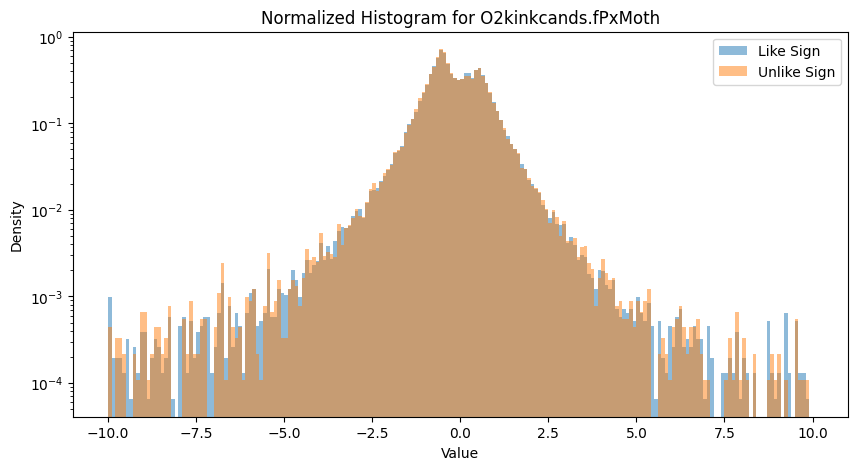

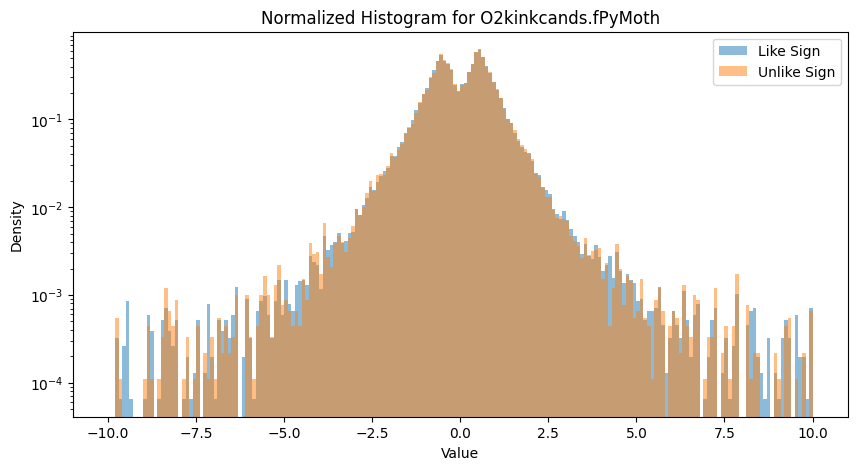

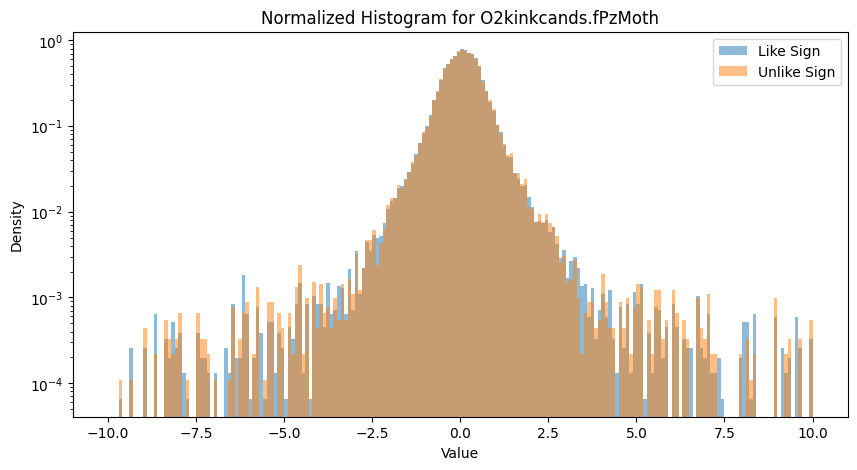

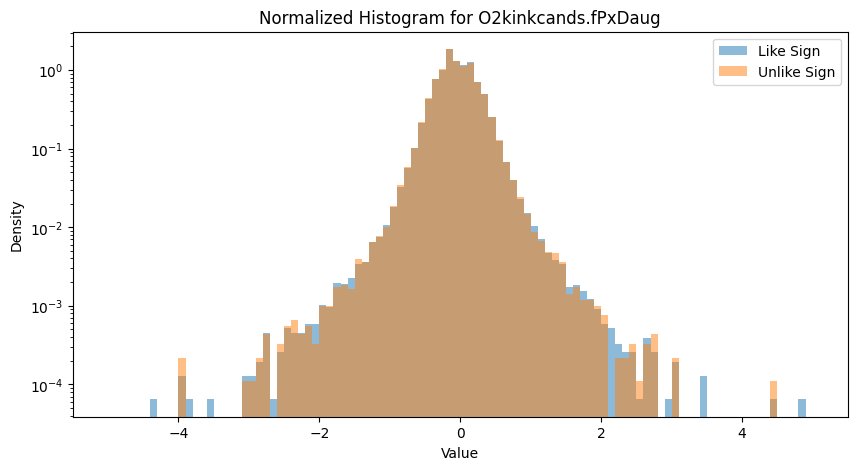

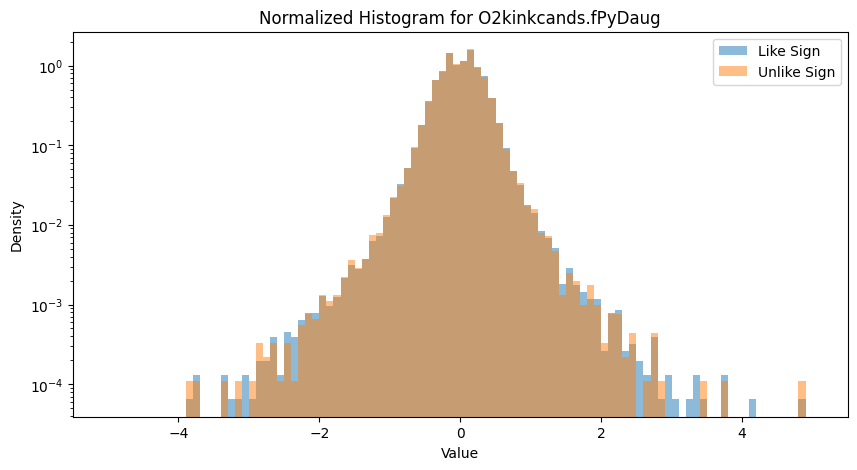

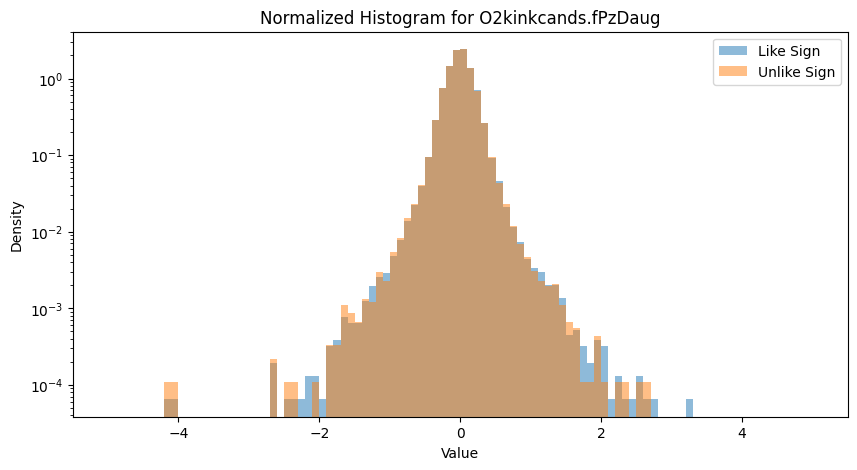

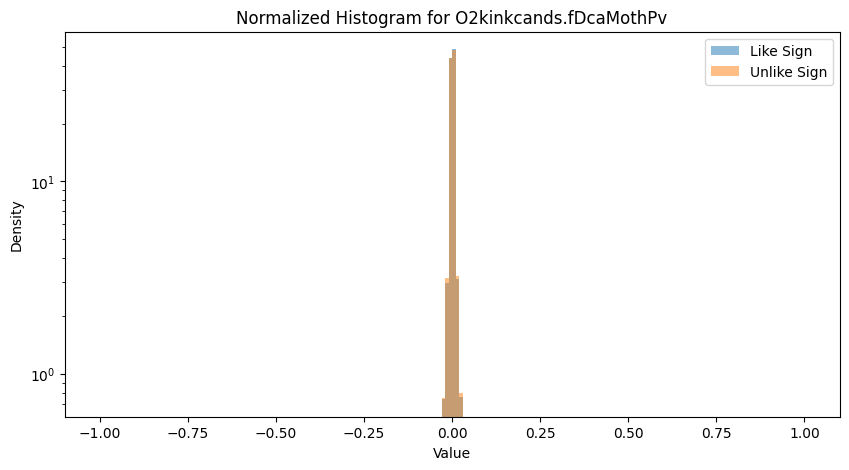

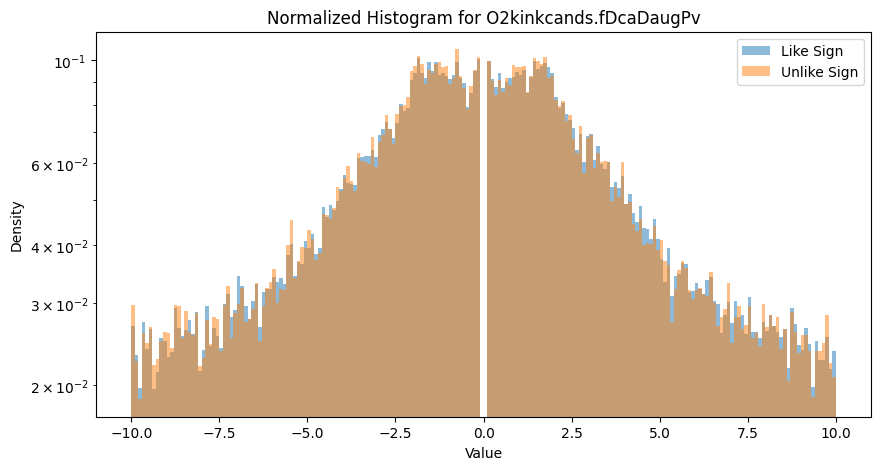

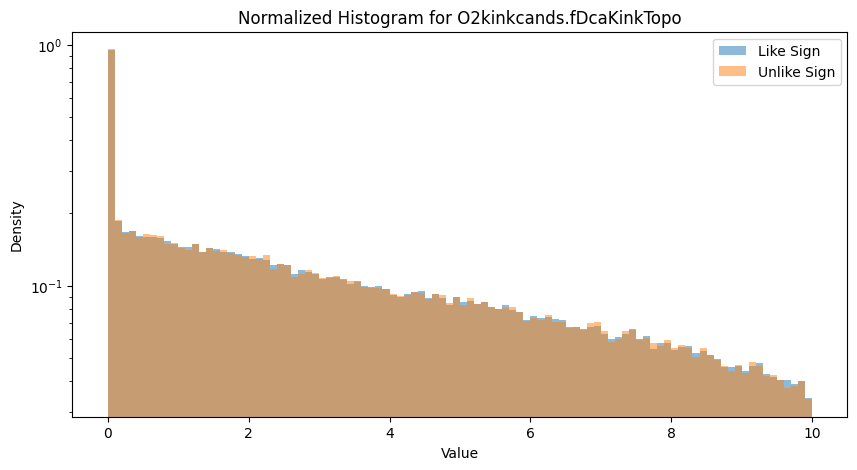

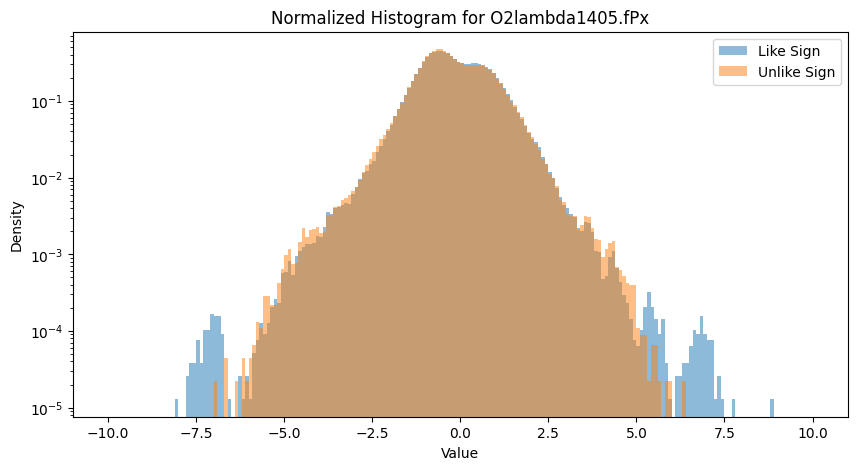

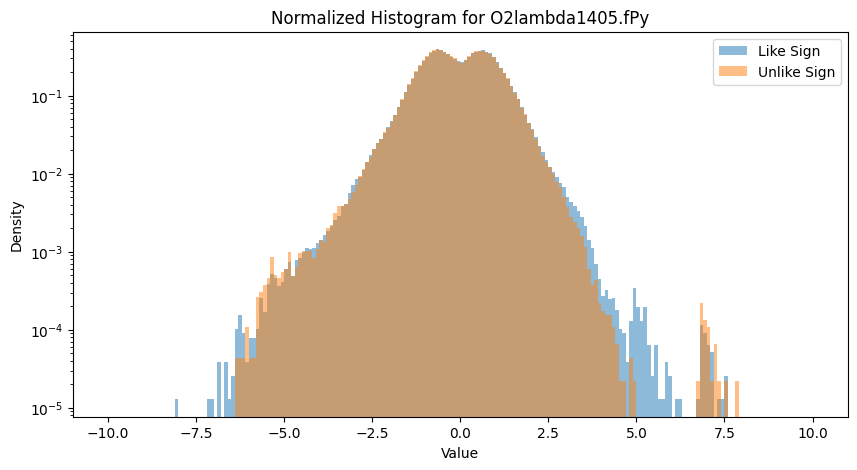

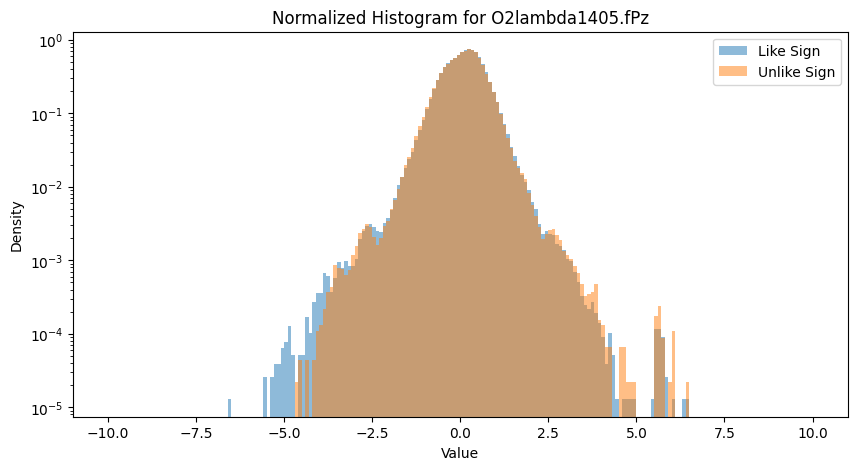

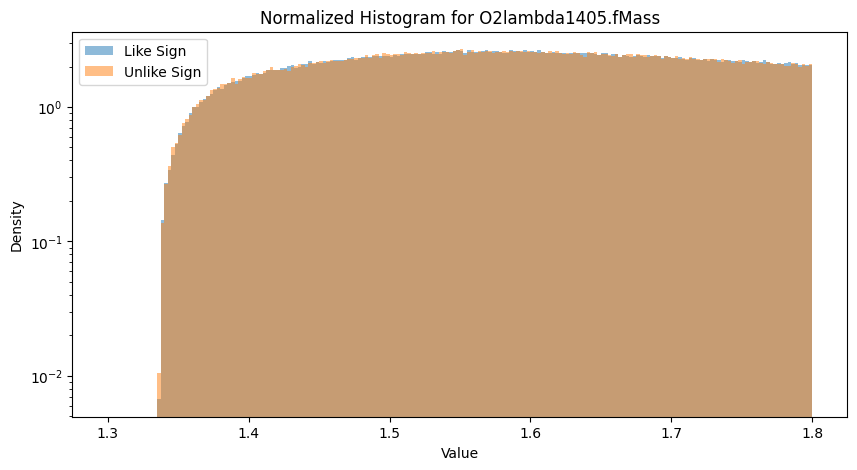

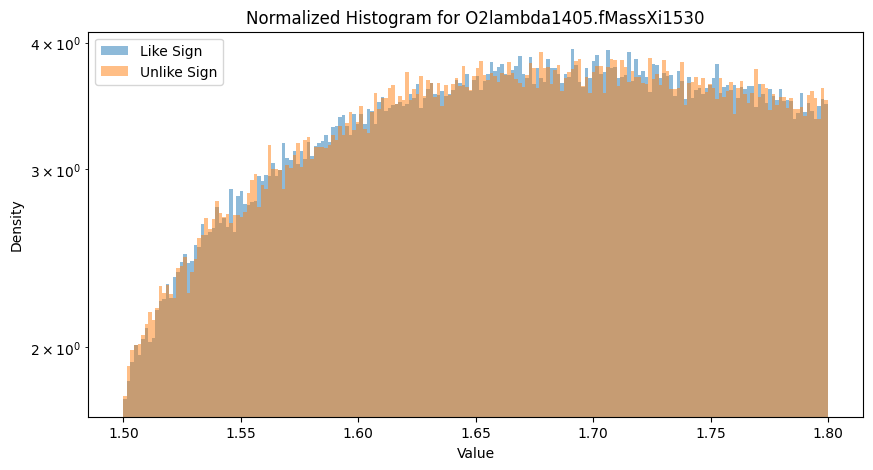

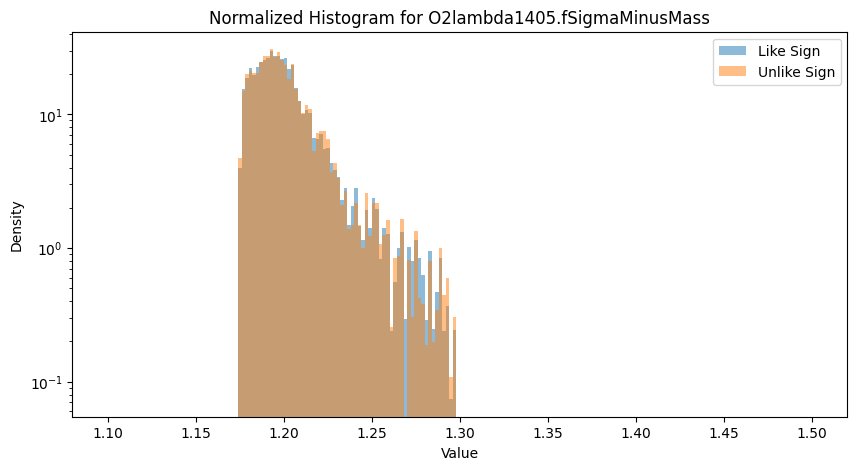

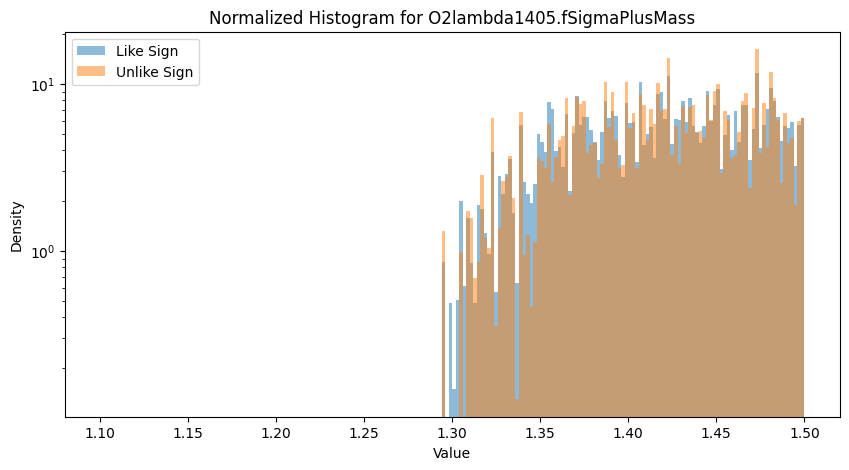

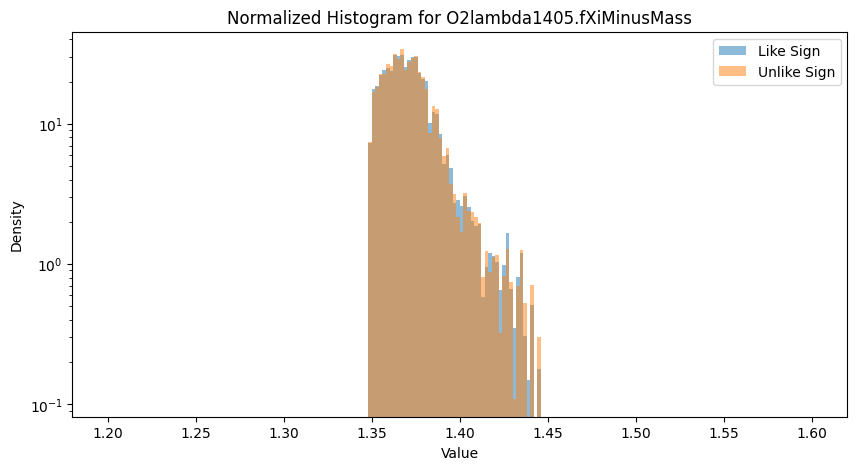

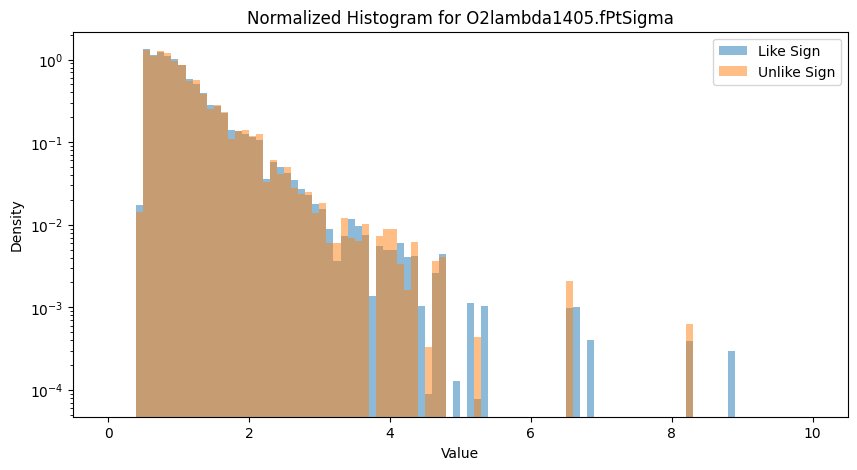

/home/mdicosta/virtenvpy/phys/lib/python3.12/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


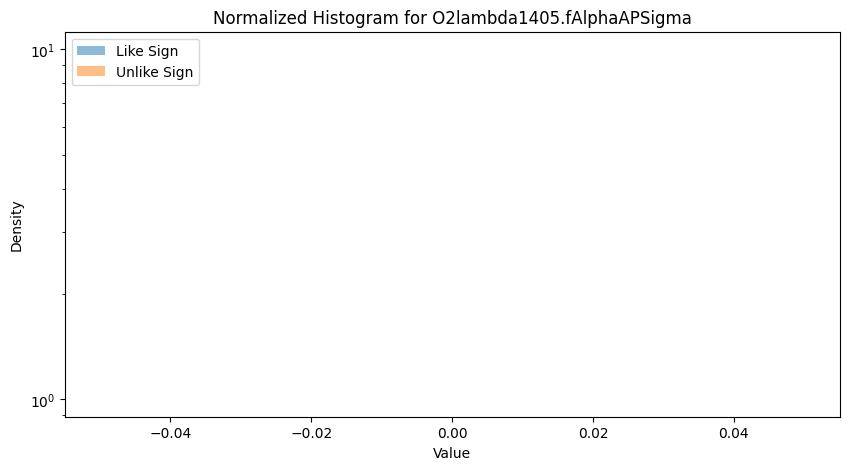

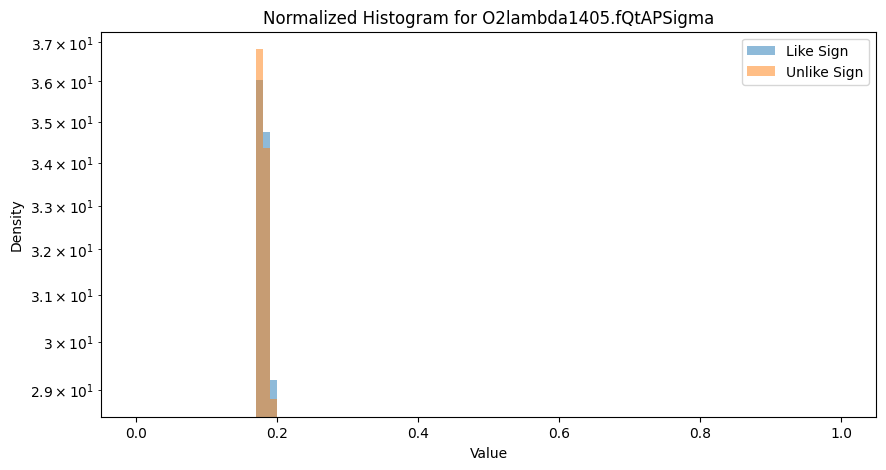

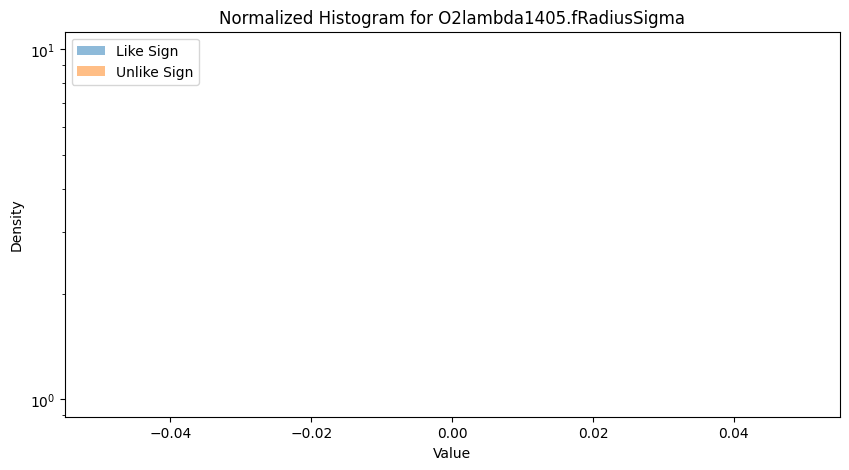

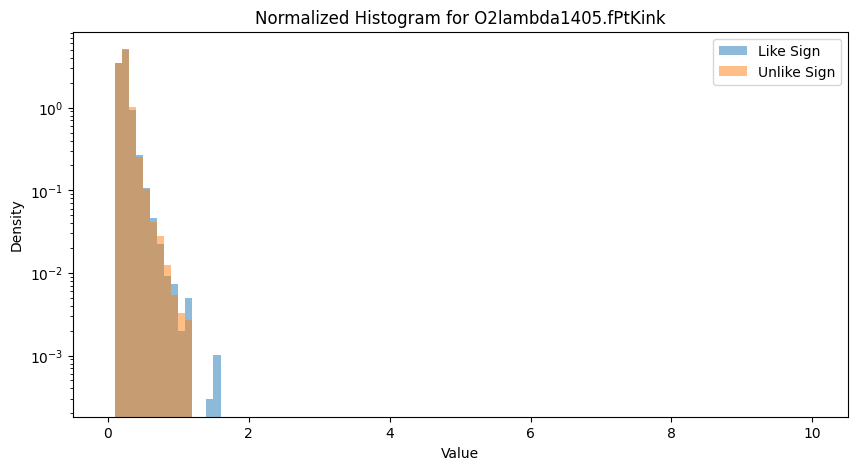

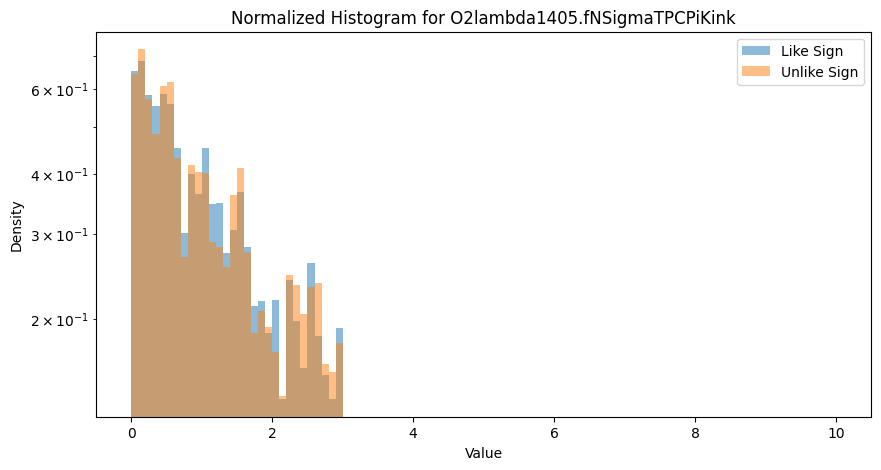

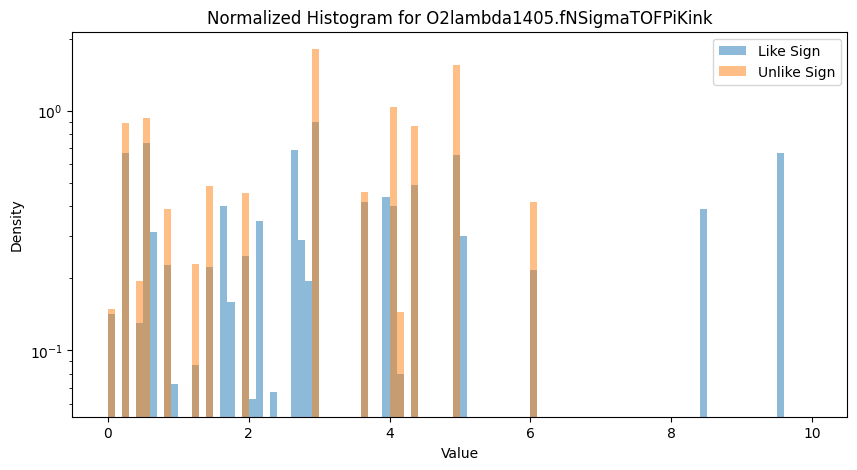

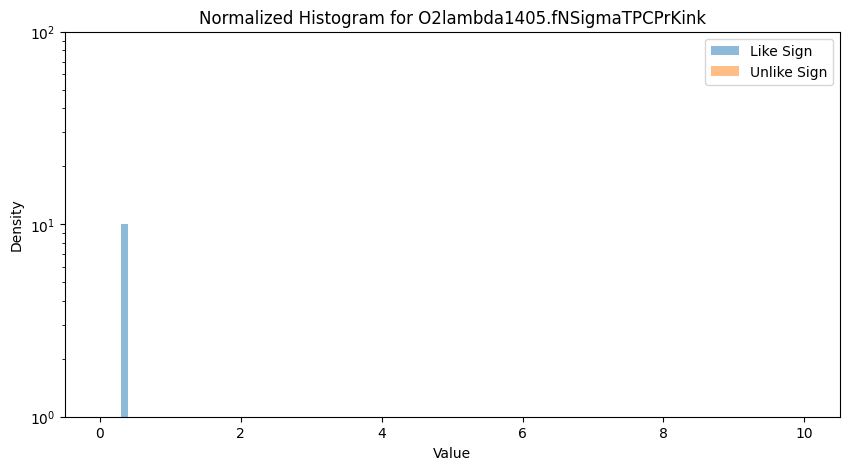

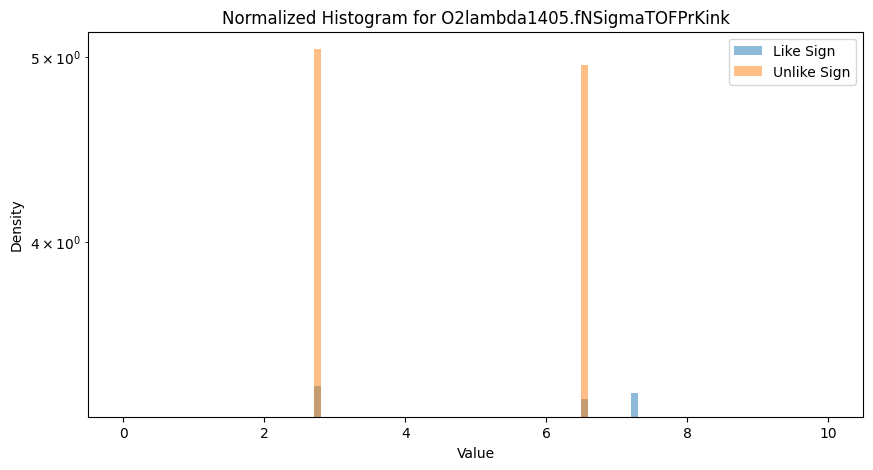

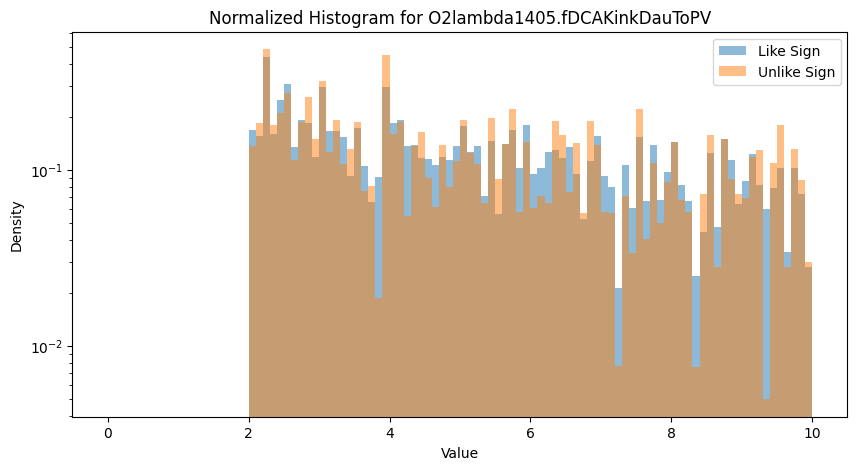

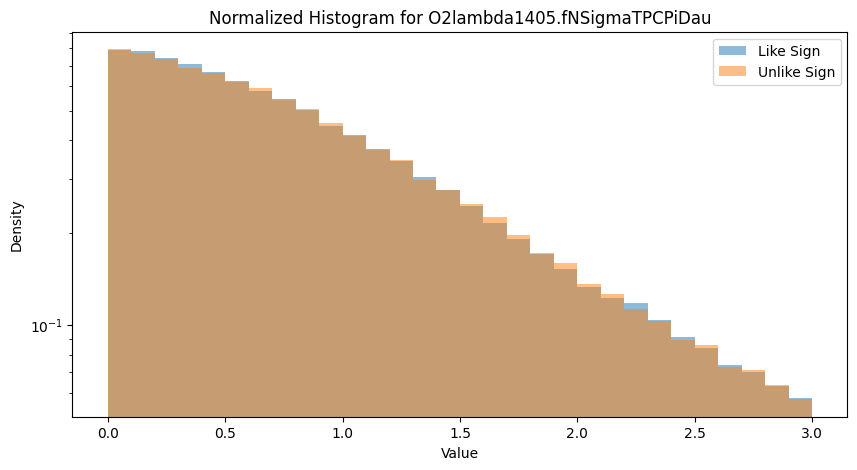

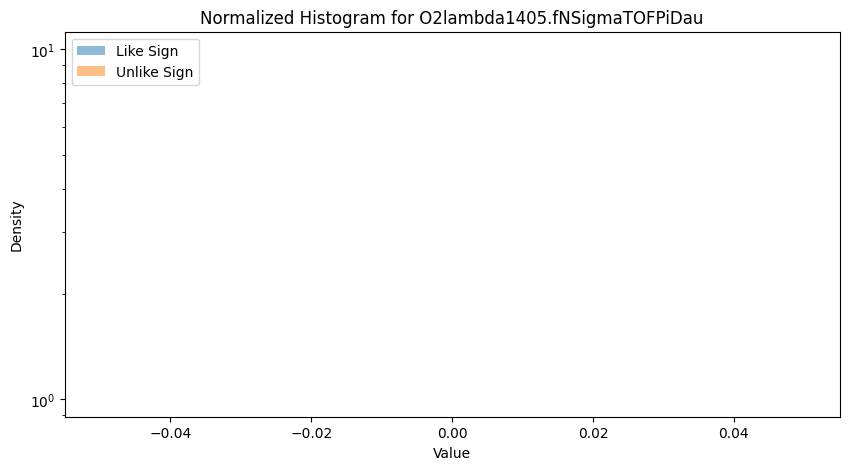

In [4]:
# Variable ranges
columns_to_draw = {
    # "O2kinkcands.fIndexCollisions": (0, 300, 300), 
    # "O2kinkcands.fIndexTracksIU_Moth": (0, 800000, 300), 
    # "O2kinkcands.fIndexTracksIU_Daug": (0, 800000, 300), 
    "O2kinkcands.fXDecVtx": (-250, 250, 500), 
    "O2kinkcands.fYDecVtx": (-250, 250, 500), 
    "O2kinkcands.fZDecVtx": (-250, 250, 500), 
    "O2kinkcands.fMothSign": (-1.5, 1.5, 3), 
    "O2kinkcands.fPxMoth": (-10, 10, 200), 
    "O2kinkcands.fPyMoth": (-10, 10, 200), 
    "O2kinkcands.fPzMoth": (-10, 10, 200), 
    "O2kinkcands.fPxDaug": (-5, 5, 100), 
    "O2kinkcands.fPyDaug": (-5, 5, 100), 
    "O2kinkcands.fPzDaug": (-5, 5, 100), 
    "O2kinkcands.fDcaMothPv": (-1, 1, 200), 
    "O2kinkcands.fDcaDaugPv": (-10, 10, 200), 
    "O2kinkcands.fDcaKinkTopo": (0, 10, 100), 
    "O2lambda1405.fPx": (-10, 10, 200), 
    "O2lambda1405.fPy": (-10, 10, 200), 
    "O2lambda1405.fPz": (-10, 10, 200), 
    "O2lambda1405.fMass": (1.3, 1.8, 200), 
    "O2lambda1405.fMassXi1530": (1.5, 1.8, 200), 
    "O2lambda1405.fSigmaMinusMass": (1.1, 1.5, 200),
    "O2lambda1405.fSigmaPlusMass": (1.1, 1.5, 200), 
    "O2lambda1405.fXiMinusMass": (1.2, 1.6, 200), 
    "O2lambda1405.fPtSigma": (0, 10, 100), 
    "O2lambda1405.fAlphaAPSigma": (0, 1, 100), 
    "O2lambda1405.fQtAPSigma": (0, 1, 100), 
    "O2lambda1405.fRadiusSigma": (0, 10, 100), 
    "O2lambda1405.fPtKink": (0, 10, 100), 
    "O2lambda1405.fNSigmaTPCPiKink": (0, 10, 100), 
    "O2lambda1405.fNSigmaTOFPiKink": (0, 10, 100), 
    "O2lambda1405.fNSigmaTPCPrKink": (0, 10, 100), 
    "O2lambda1405.fNSigmaTOFPrKink": (0, 10, 100), 
    "O2lambda1405.fDCAKinkDauToPV": (0, 10, 100), 
    "O2lambda1405.fNSigmaTPCPiDau": (0, 3, 30), 
    "O2lambda1405.fNSigmaTOFPiDau": (0, 3, 30)
}


# Plot all columns normalized for like-sign and unlike-sign
for col in columns_to_draw.keys():
    if col in all_data_unlike_sign:
        plt.figure(figsize=(10, 5))
        col_settings = columns_to_draw.get(col, (min(min(all_data_like_sign[col]), min(all_data_unlike_sign[col])), max(max(all_data_like_sign[col]), max(all_data_unlike_sign[col])), 100))
        plt.hist(all_data_like_sign[col], bins=col_settings[2], range=(col_settings[0], col_settings[1]), alpha=0.5, label='Like Sign', density=True, log=True)
        plt.hist(all_data_unlike_sign[col], bins=col_settings[2], range=(col_settings[0], col_settings[1]), alpha=0.5, label='Unlike Sign', density=True, log=True)
        plt.title(f"Normalized Histogram for {col}")
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.legend()
        plt.show()
